In [1]:
import numpy as numpy
import pandas as pd
import os

In [2]:
# Define paths
DATASET_PATH = "D:/LA/LA"
PROTOCOLS_PATH = os.path.join(DATASET_PATH, "ASVspoof2019_LA_cm_protocols")

# Define protocol files
protocol_files = {
    "train": os.path.join(PROTOCOLS_PATH, "ASVspoof2019.LA.cm.train.trn.txt"),
    "dev": os.path.join(PROTOCOLS_PATH, "ASVspoof2019.LA.cm.dev.trl.txt"),
    "eval": os.path.join(PROTOCOLS_PATH, "ASVspoof2019.LA.cm.eval.trl.txt"),
}

# Define audio directories
audio_dirs = {
    "train": os.path.join(DATASET_PATH, "ASVspoof2019_LA_train/flac"),
    "dev": os.path.join(DATASET_PATH, "ASVspoof2019_LA_dev/flac"),
    "eval": os.path.join(DATASET_PATH, "ASVspoof2019_LA_eval/flac"),
}

In [3]:
# Đọc file protocol vào DataFrame
def load_protocol(file_path):
    df = pd.read_csv(file_path, sep=" ", header=None, names=["speaker_id", "file_name", "system_id", "attack_type", "label"])
    return df

# Kiểm tra thông tin của từng tập dữ liệu
for key, path in protocol_files.items():
    print(f"📂 Dataset: {key.upper()}")
    df = load_protocol(path)
    print(df.info())  # Thông tin dữ liệu

📂 Dataset: TRAIN
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25380 entries, 0 to 25379
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   speaker_id   25380 non-null  object
 1   file_name    25380 non-null  object
 2   system_id    25380 non-null  object
 3   attack_type  25380 non-null  object
 4   label        25380 non-null  object
dtypes: object(5)
memory usage: 991.5+ KB
None
📂 Dataset: DEV
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24844 entries, 0 to 24843
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   speaker_id   24844 non-null  object
 1   file_name    24844 non-null  object
 2   system_id    24844 non-null  object
 3   attack_type  24844 non-null  object
 4   label        24844 non-null  object
dtypes: object(5)
memory usage: 970.6+ KB
None
📂 Dataset: EVAL
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71237 entries, 0 t

In [7]:
# kiểm tra giá trị rỗng
def check_missing_values(file_path):
    df = pd.read_csv(file_path, sep=" ", header=None, names=["speaker_id", "file_name", "system_id", "attack_type", "label"])
    missing_values = df.isnull().sum()  # Kiểm tra số lượng giá trị rỗng trong mỗi cột
    print(f"📂 Checking file: {os.path.basename(file_path)}")
    print(missing_values)

# Kiểm tra tất cả các tệp
for key, path in protocol_files.items():
    check_missing_values(path)

📂 Checking file: ASVspoof2019.LA.cm.train.trn.txt
speaker_id     0
file_name      0
system_id      0
attack_type    0
label          0
dtype: int64
📂 Checking file: ASVspoof2019.LA.cm.dev.trl.txt
speaker_id     0
file_name      0
system_id      0
attack_type    0
label          0
dtype: int64
📂 Checking file: ASVspoof2019.LA.cm.eval.trl.txt
speaker_id     0
file_name      0
system_id      0
attack_type    0
label          0
dtype: int64


Câu 1: Số lượng file bonafide và spoof trong từng tập (train, dev, eval) là bao nhiêu?

Câu 2: Trong tập spoof, có bao nhiêu loại tấn công khác nhau ?

Câu 3: Sự khác biệt giữa dạng sóng của giọng thật và giọng giả là gì?

Câu 4: Giọng giả, giọng thật khác nhau như thế nào khi thực hiện bằng Spectrogram?

Câu 5: Sự phân bố độ dài của từng tập như thế nào?

***Câu 1: Số lượng file bonafide và spoof trong từng tập (train, dev, eval) là bao nhiêu?***

C:\Users\VanKhanh\AppData\Roaming\Python\Python311\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Users\VanKhanh\AppData\Roaming\Python\Python311\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Users\VanKhanh\AppData\Roaming\Python\Python311\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\User

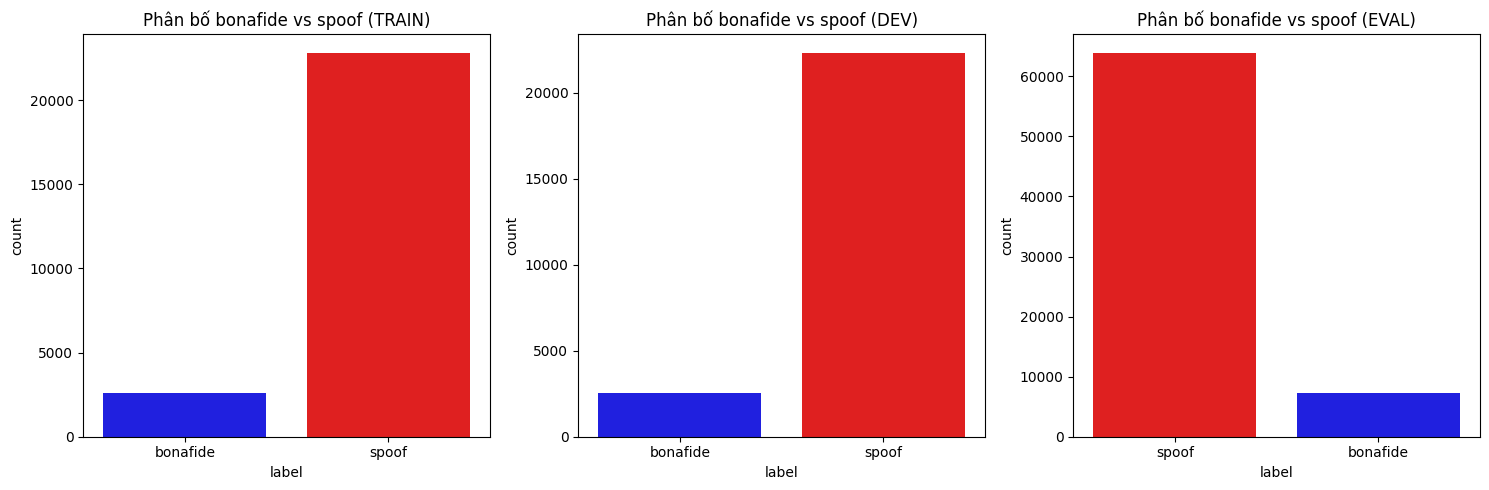

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# Tạo biểu đồ phân bố
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, (key, path) in enumerate(protocol_files.items()):
    df = load_protocol(path)
    sns.countplot(x=df["label"], ax=axes[i], hue=df["label"], palette={"bonafide": "blue", "spoof": "red"})
    axes[i].set_title(f"Phân bố bonafide vs spoof ({key.upper()})")

plt.tight_layout()
plt.show()

***Câu 2: Trong tập spoof, có bao nhiêu loại tấn công khác nhau ?***

C:\Users\VanKhanh\AppData\Roaming\Python\Python311\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Users\VanKhanh\AppData\Roaming\Python\Python311\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Users\VanKhanh\AppData\Roaming\Python\Python311\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\User

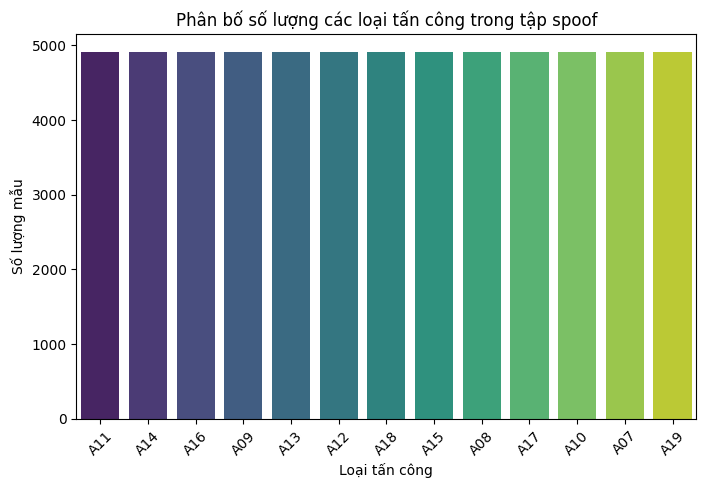

In [23]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Lọc các mẫu spoof
spoof_df = df[df["label"] == "spoof"]

# Đếm số lượng mỗi loại tấn công
attack_counts = spoof_df["attack_type"].value_counts().reset_index()
attack_counts.columns = ["attack_type", "count"]

# Trực quan hóa
plt.figure(figsize=(8, 5))
ax = sns.barplot(data=attack_counts, x="attack_type", y="count", hue="attack_type", dodge=False, legend=False, palette="viridis")

# Gắn nhãn
plt.xlabel("Loại tấn công")
plt.ylabel("Số lượng mẫu")
plt.title("Phân bố số lượng các loại tấn công trong tập spoof")
plt.xticks(rotation=45)
plt.show()

***Câu 3: Sự khác biệt giữa dạng sóng của giọng thật và giọng giả là gì?***

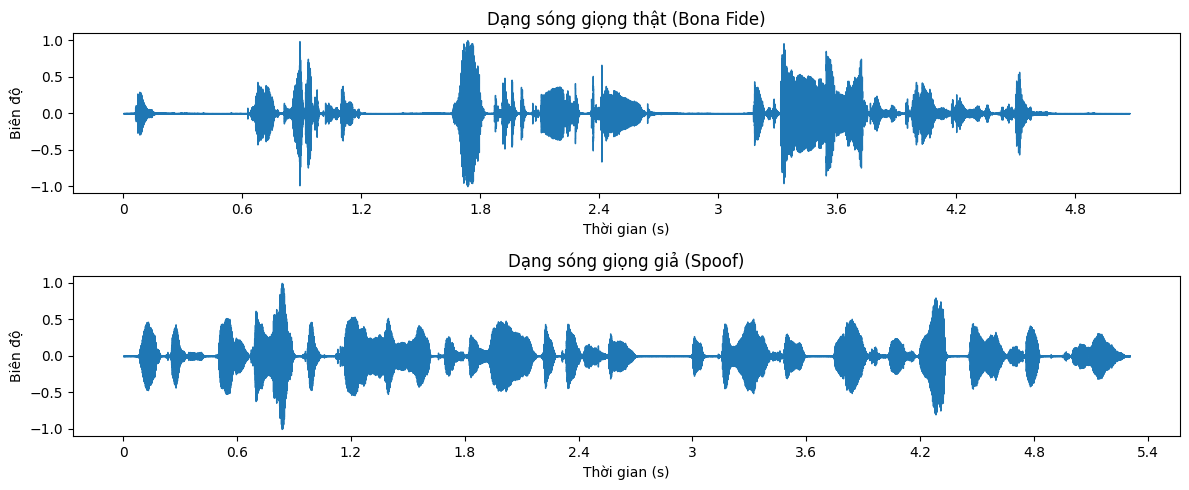

In [27]:
import librosa
import librosa.display
import matplotlib.pyplot as plt

# Load file âm thanh (đổi thành đường dẫn phù hợp)
real_audio, sr = librosa.load("D:/LA/LA/ASVspoof2019_LA_train/flac/LA_T_1007615.flac", sr=None)  #bonafile
fake_audio, sr = librosa.load("D:/LA/LA/ASVspoof2019_LA_train/flac/LA_T_4025620.flac", sr=None)  #spoof

# Vẽ dạng sóng
plt.figure(figsize=(12, 5))

plt.subplot(2, 1, 1)
librosa.display.waveshow(real_audio, sr=sr)
plt.title("Dạng sóng giọng thật (Bona Fide)")
plt.xlabel("Thời gian (s)")
plt.ylabel("Biên độ")

plt.subplot(2, 1, 2)
librosa.display.waveshow(fake_audio, sr=sr)
plt.title("Dạng sóng giọng giả (Spoof)")
plt.xlabel("Thời gian (s)")
plt.ylabel("Biên độ")

plt.tight_layout()
plt.show()


**Câu 4: Giọng giả, giọng thật khác nhau như thế nào khi thực hiện bằng Spectrogram?**

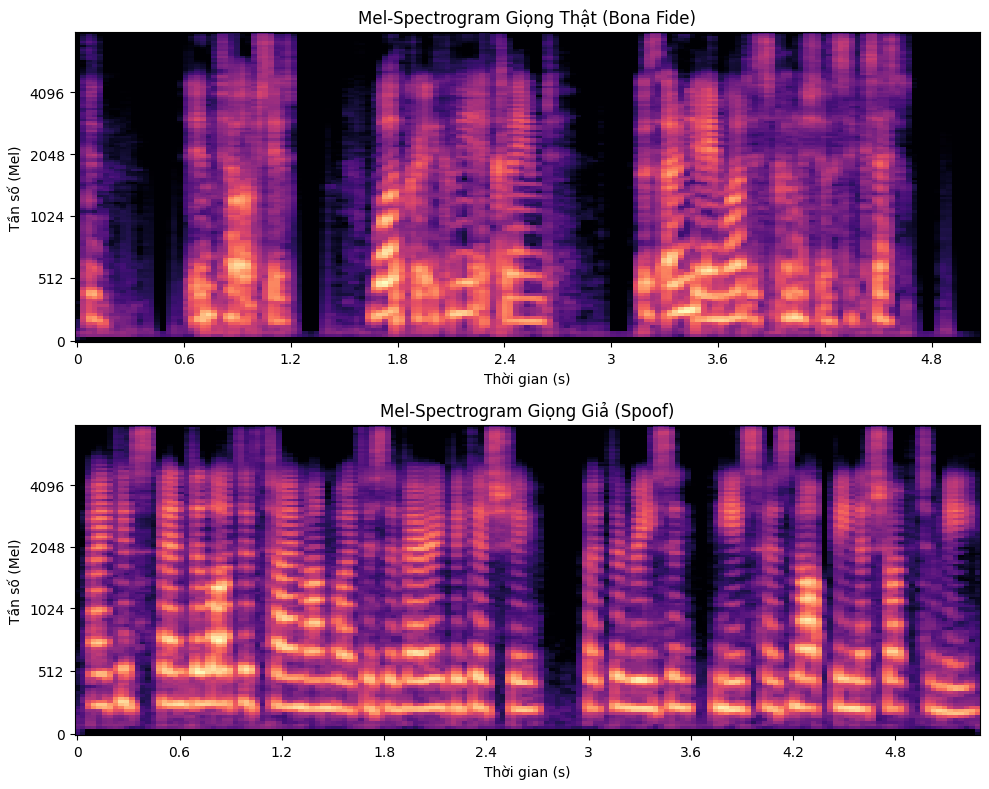

In [38]:
import numpy as np
import matplotlib.pyplot as plt
import librosa
import librosa.display

# Đọc hai file âm thanh: giọng thật (bona fide) và giọng giả (spoof)
bona_fide_path = "D:/LA/LA/ASVspoof2019_LA_train/flac/LA_T_1007615.flac"  # Thay bằng đường dẫn thực tế
spoof_path = "D:/LA/LA/ASVspoof2019_LA_train/flac/LA_T_4025620.flac"          # Thay bằng đường dẫn thực tế

# Load audio
y_bona, sr_bona = librosa.load(bona_fide_path, sr=None)
y_spoof, sr_spoof = librosa.load(spoof_path, sr=None)

# Tính spectrogram (Mel-spectrogram)
S_bona = librosa.feature.melspectrogram(y=y_bona, sr=sr_bona, n_mels=128, fmax=8000)
S_spoof = librosa.feature.melspectrogram(y=y_spoof, sr=sr_spoof, n_mels=128, fmax=8000)

# Chuyển sang dB
S_dB_bona = librosa.power_to_db(S_bona, ref=np.max)
S_dB_spoof = librosa.power_to_db(S_spoof, ref=np.max)

# Vẽ hình
fig, ax = plt.subplots(nrows=2, figsize=(10, 8))

# Spectrogram giọng thật
librosa.display.specshow(S_dB_bona, sr=sr_bona, x_axis="time", y_axis="mel", ax=ax[0])
ax[0].set_title("Mel-Spectrogram Giọng Thật (Bona Fide)")
ax[0].set_xlabel("Thời gian (s)")
ax[0].set_ylabel("Tần số (Mel)")

# Spectrogram giọng giả
librosa.display.specshow(S_dB_spoof, sr=sr_spoof, x_axis="time", y_axis="mel", ax=ax[1])
ax[1].set_title("Mel-Spectrogram Giọng Giả (Spoof)")
ax[1].set_xlabel("Thời gian (s)")
ax[1].set_ylabel("Tần số (Mel)")

#plt.colorbar(librosa.display.specshow(S_dB_spoof, sr=sr_spoof, x_axis="time", y_axis="mel", ax=ax[1]), ax=ax[1])
plt.tight_layout()
plt.show()


**Câu 5: Sự phân bố độ dài của từng tập như thế nào?**

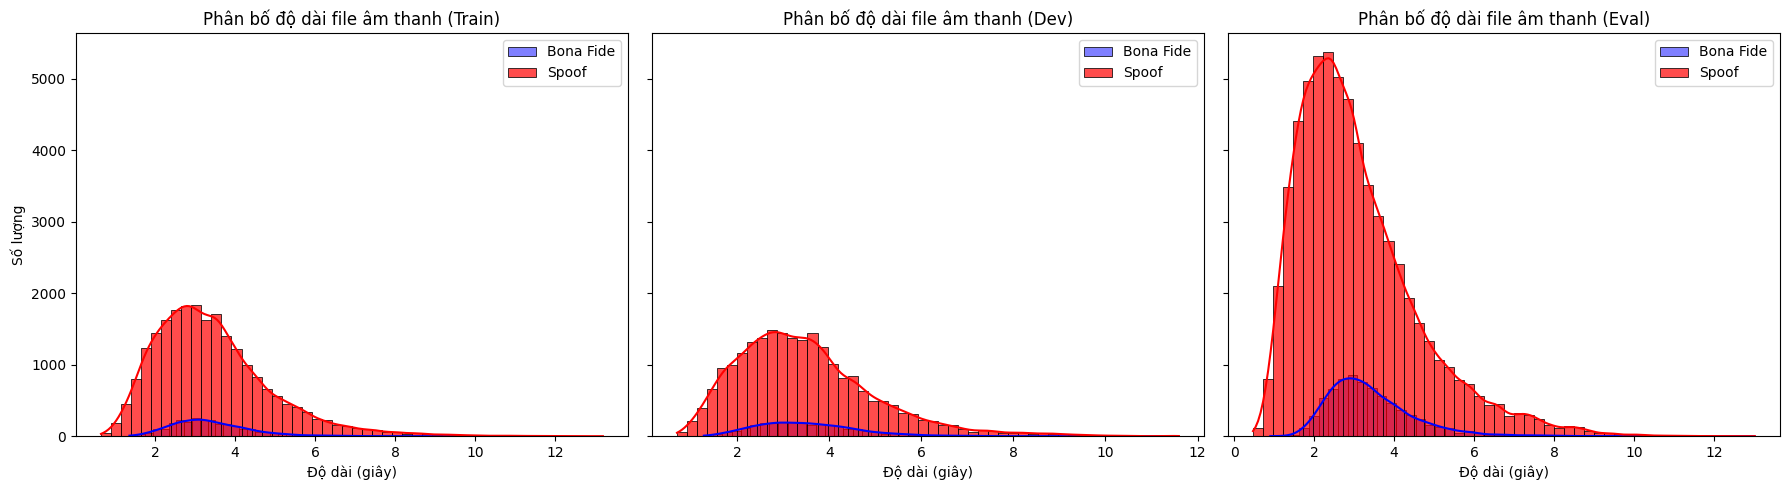

In [1]:
import os
import librosa
import matplotlib.pyplot as plt
import seaborn as sns

# Đường dẫn tới thư mục chứa file âm thanh
DATASETS = {
    "Train": {
        "audio_dir": "D:/LA/LA/ASVspoof2019_LA_train/flac/",
        "protocol_file": "D:/LA/LA/ASVspoof2019_LA_cm_protocols/ASVspoof2019.LA.cm.train.trn.txt"
    },
    "Dev": {
        "audio_dir": "D:/LA/LA/ASVspoof2019_LA_dev/flac/",
        "protocol_file": "D:/LA/LA/ASVspoof2019_LA_cm_protocols/ASVspoof2019.LA.cm.dev.trl.txt"
    },
    "Eval": {
        "audio_dir": "D:/LA/LA/ASVspoof2019_LA_eval/flac/",
        "protocol_file": "D:/LA/LA/ASVspoof2019_LA_cm_protocols/ASVspoof2019.LA.cm.eval.trl.txt"
    }
}

# Hàm đọc nhãn từ protocol file
def read_labels(protocol_file):
    bona_fide_files, spoof_files = [], []
    with open(protocol_file, "r") as f:
        for line in f:
            parts = line.strip().split()
            file_name, label = parts[1], parts[-1]  # File và nhãn (bonafide/spoof)
            if label == "bonafide":
                bona_fide_files.append(file_name)
            else:
                spoof_files.append(file_name)
    return bona_fide_files, spoof_files

# Hàm lấy độ dài file âm thanh
def get_duration(file_list, audio_dir):
    durations = []
    for file in file_list:
        file_path = os.path.join(audio_dir, file + ".flac")  # Thay .flac nếu định dạng khác
        y, sr = librosa.load(file_path, sr=None)
        durations.append(len(y) / sr)  # Độ dài (giây)
    return durations

# Lưu độ dài của mỗi tập dữ liệu
durations = {}

for dataset, paths in DATASETS.items():
    bona_fide_files, spoof_files = read_labels(paths["protocol_file"])
    durations[dataset] = {
        "bona_fide": get_duration(bona_fide_files, paths["audio_dir"]),
        "spoof": get_duration(spoof_files, paths["audio_dir"])
    }

# Vẽ histogram riêng cho từng tập
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for i, dataset in enumerate(["Train", "Dev", "Eval"]):
    ax = axes[i]
    sns.histplot(durations[dataset]["bona_fide"], bins=50, color="blue", kde=True, label="Bona Fide", ax=ax)
    sns.histplot(durations[dataset]["spoof"], bins=50, color="red", kde=True, label="Spoof", ax=ax, alpha=0.7)
    ax.set_title(f"Phân bố độ dài file âm thanh ({dataset})")
    ax.set_xlabel("Độ dài (giây)")
    ax.set_ylabel("Số lượng")
    ax.legend()

plt.tight_layout()
plt.show()


***Câu 6: Sự khác biệt về dạng sóng của tín hiệu gốc và tín hiệu có nhiễu là gì?***

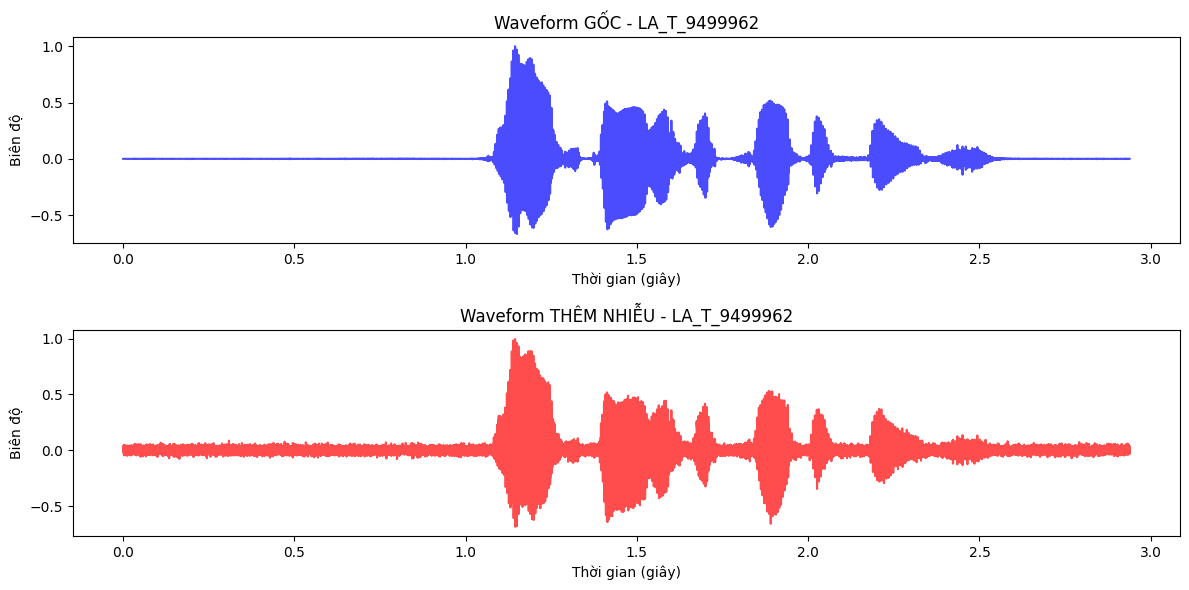

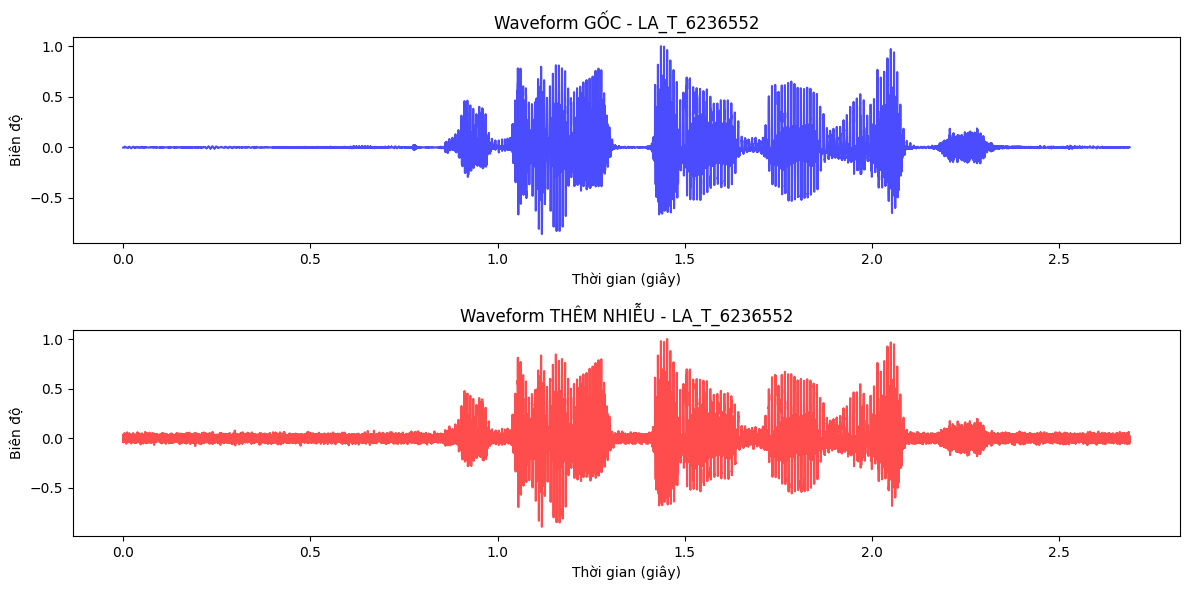

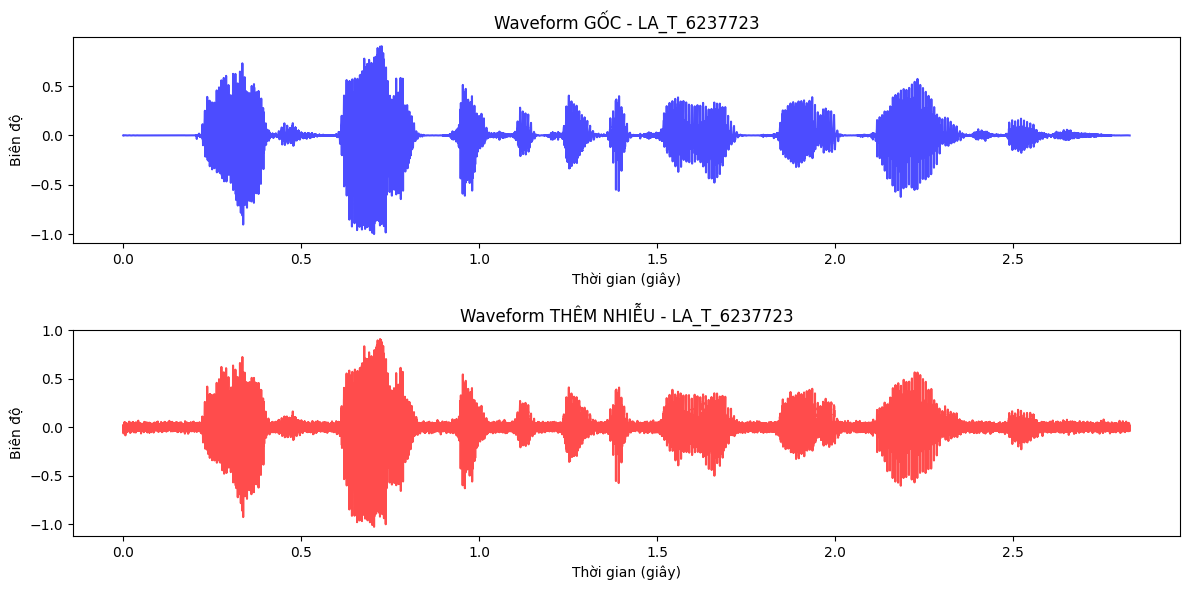

In [11]:
import os
import librosa
import numpy as np
import matplotlib.pyplot as plt

# Đường dẫn tới thư mục train
AUDIO_DIR = "D:/LA/LA/ASVspoof2019_LA_train/flac/"  
PROTOCOL_FILE = "D:/LA/LA/ASVspoof2019_LA_cm_protocols/ASVspoof2019.LA.cm.train.trn.txt"  

# Đọc danh sách file âm thanh bona fide và spoof
bona_fide_files = []
spoof_files = []

with open(PROTOCOL_FILE, "r") as f:
    for line in f:
        parts = line.strip().split()
        file_name, label = parts[1], parts[-1]  
        if label == "bonafide":
            bona_fide_files.append(file_name)
        else:
            spoof_files.append(file_name)

# Hàm thêm nhiễu Gaussian vào tín hiệu âm thanh
def add_noise(y, noise_factor=0.02):
    noise = noise_factor * np.random.randn(len(y))
    return y + noise

# Hàm vẽ waveform trước & sau khi thêm nhiễu
def plot_waveform(y, y_noisy, sr, file_name):
    plt.figure(figsize=(12, 6))

    # Biểu đồ 1: Waveform gốc
    plt.subplot(2, 1, 1)
    plt.plot(np.linspace(0, len(y) / sr, len(y)), y, color="blue", alpha=0.7)
    plt.title(f"Waveform GỐC - {file_name}")
    plt.xlabel("Thời gian (giây)")
    plt.ylabel("Biên độ")

    # Biểu đồ 2: Waveform sau khi thêm nhiễu
    plt.subplot(2, 1, 2)
    plt.plot(np.linspace(0, len(y_noisy) / sr, len(y_noisy)), y_noisy, color="red", alpha=0.7)
    plt.title(f"Waveform THÊM NHIỄU - {file_name}")
    plt.xlabel("Thời gian (giây)")
    plt.ylabel("Biên độ")

    plt.tight_layout()
    plt.show()

# Chọn một số file ngẫu nhiên để trực quan
sample_files = np.random.choice(bona_fide_files + spoof_files, 3, replace=False)

for file_name in sample_files:
    file_path = os.path.join(AUDIO_DIR, file_name + ".flac")
    y, sr = librosa.load(file_path, sr=None)
    y_noisy = add_noise(y, noise_factor=0.02)
    
    # Vẽ waveform trước & sau khi thêm nhiễu
    plot_waveform(y, y_noisy, sr, file_name)
